In [2]:
%load_ext autoreload
%autoreload 2
%cd /home/albin/egna_proj/block_puzzle_rl/

/home/albin/egna_proj/block_puzzle_rl


/home/albin/egna_proj/block_puzzle_rl/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


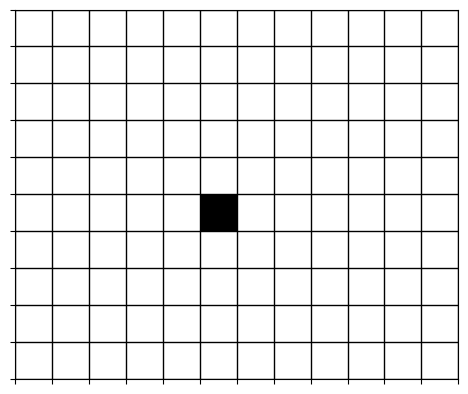

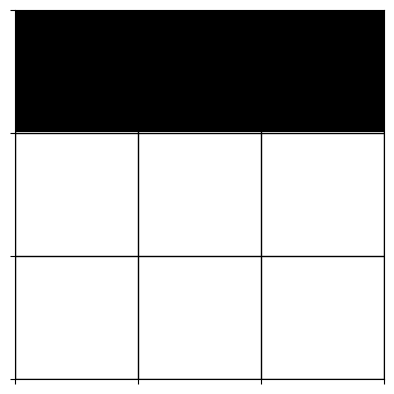

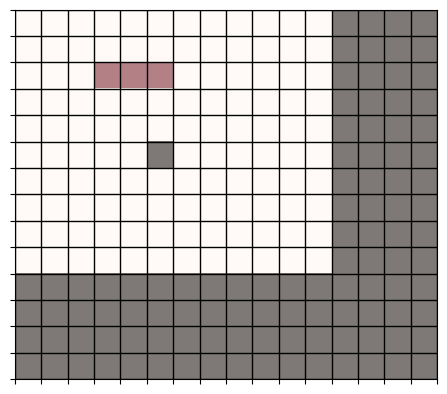

In [3]:
from game.grid import Grid
from game.block import TypeBlock
import numpy as np
import game.plot_game as plot_game

grid = Grid(12, 10, block_size=4)  

# Dummy block
block = TypeBlock(4, 0)  # You may adapt constructor
block_array = block.grid()

# Place something in the grid for testing
grid.grid_[5, 5] = 1
plot_game.plot_grid(grid.get_game_grid())

# Plot just the block
plot_game.plot_block(block_array)

# Plot proposed placement of block at (2, 3)
plot_game.plot_placement(grid.grid_, block_array, 2, 3)

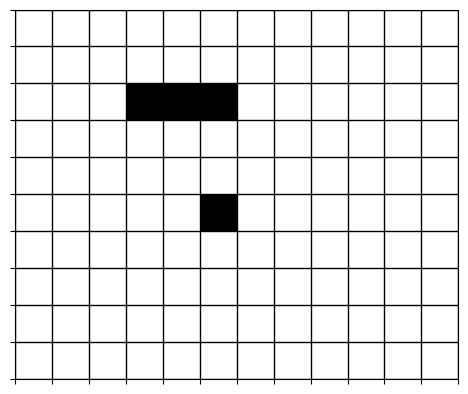

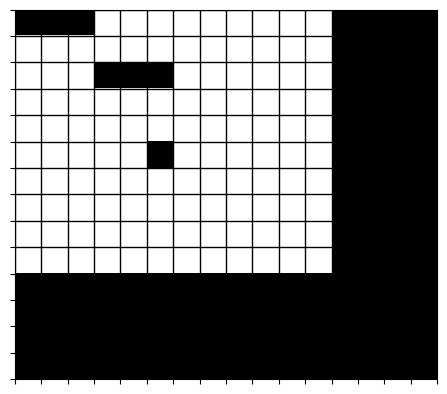

In [4]:
if grid.is_valid_placement(block, 2, 3):
    grid.place_block(block, 2, 3)
plot_game.plot_grid(grid.get_game_grid())
if grid.is_valid_placement(block, 0, 0):
    grid.place_block(block, 0, 0)
plot_game.plot_grid(grid.get_padded_grid())

In [5]:
from IPython.display import display, Markdown

In [6]:
plot_game.render_text(grid.get_game_grid())
print()
test_block = TypeBlock(8, 0)
plot_game.render_text(test_block.grid())

■ ■ ■ □ □ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □ □ □ □ □
□ □ □ ■ ■ ■ □ □ □ □ □ □
□ □ □ □ □ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □ □ □ □ □
□ □ □ □ □ ■ □ □ □ □ □ □
□ □ □ □ □ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □ □ □ □ □

■ ■ □
□ ■ ■
□ □ □


In [7]:
grid = Grid(4, 4, block_size=4)
grid.is_valid_placement(test_block, 1, 2)
plot_game.render_text(grid.get_game_grid())
print()
test_block = TypeBlock(8, 0)
plot_game.render_text(test_block.grid())

□ □ □ □
□ □ □ □
□ □ □ □
□ □ □ □

■ ■ □
□ ■ ■
□ □ □


In [8]:
grid.place_block(test_block, 0, 1)

In [9]:
plot_game.render_text(grid.get_game_grid())

□ ■ ■ □
□ □ ■ ■
□ □ □ □
□ □ □ □


In [10]:
test_block = TypeBlock(10, 0)
plot_game.render_text(test_block.grid())
valid_placements = grid.get_all_valid_placements(test_block)
valid_placements

■ ■ ■ ■
□ □ □ □
□ □ □ □
□ □ □ □


array([[False, False, False, False, False],
       [False, False, False, False, False],
       [ True, False, False, False, False],
       [ True, False, False, False, False],
       [False, False, False, False, False]])

In [11]:
np.where(valid_placements)

(array([2, 3]), array([0, 0]))

In [12]:
grid.is_valid_placement(test_block, 2, 0)

np.True_

In [13]:
grid.place_block(test_block, 2, 0)
plot_game.render_text(grid.get_game_grid())

□ ■ ■ □
□ □ ■ ■
■ ■ ■ ■
□ □ □ □


In [14]:
from agent.utils import encode_state_cnn, shift_array, generate_shifted_channels
test_grid = np.zeros((4, 4))
test_block = np.array([[1, 0], [0, 0]])
test_block2 = np.array([[1, 1], [1, 0]])

In [15]:
shift_array(test_block, 0, 1)

array([[0, 0],
       [1, 0]])

In [16]:
from agent.utils import encode_state_cnn, shift_array

test_grid = np.zeros((4,4))
test_block = np.array([[1, 0], [0, 0]])
result = encode_state_cnn({'grid': test_grid, 'blocks': [test_block, test_block2]})
result

array([[[0, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 0, 0, 0, 0]],

       [[0, 0, 1, 0, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 1, 1],
        [0, 0, 1, 0, 0, 1, 1, 0, 1],
        [0, 0, 0, 0, 1, 0, 1, 1, 1]],

       [[0, 1, 1, 0, 0, 0, 1, 0, 0],
        [0, 0, 1, 1, 1, 0, 0, 0, 1],
        [0, 1, 1, 0, 1, 0, 1, 0, 0],
        [0, 0, 1, 1, 1, 0, 0, 0, 1]],

       [[0, 0, 1, 0, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 1, 1],
        [0, 0, 1, 0, 0, 1, 1, 0, 1],
        [0, 0, 0, 0, 1, 0, 1, 1, 1]]], dtype=uint8)

In [23]:
from game.plot_game import render_text_with_blocks, render_text

render_text_with_blocks(test_grid, [test_block, test_block2])

□ □ □ □ | ■ □  ■ ■
□ □ □ □ | □ □  ■ □
□ □ □ □ |
□ □ □ □ |


In [26]:
from agent.utils import encode_state_cnn_channeled

test_grid = np.zeros((6, 6))
test_block = np.array([[1, 1], [0, 0]])
test_block2 = np.array([[1, 1], [1, 0]])

state = {
    'grid': test_grid,
    'blocks': [test_block, test_block2]
}

encoded = encode_state_cnn_channeled(state)

for channel in range(encoded.shape[0]):
    render_text(encoded[channel, :, :])
    print()

□ □ □ □ □ □
□ □ □ □ □ □
□ □ □ □ □ □
□ □ □ □ □ □
□ □ □ □ □ □
□ □ □ □ □ □

□ □ □ □ □ □
□ □ □ □ □ □
□ □ ■ ■ □ □
□ □ □ □ □ □
□ □ □ □ □ □
□ □ □ □ □ □

□ □ □ □ □ □
□ □ □ □ □ □
□ □ ■ ■ □ □
□ □ ■ □ □ □
□ □ □ □ □ □
□ □ □ □ □ □

